In [1]:
import pandas as pd
retail_df = pd.read_csv('../data/clustering/Online Retail.csv')

retail_df.describe()
retail_df.info()
retail_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# remove rows having description is NULL
clean_retail_df = retail_df.dropna(subset=['Description'])
# FIRST we will see if we forwardfill customer ID then how it performs
clean_retail_df['CustomerID'] = clean_retail_df['CustomerID'].ffill()

clean_retail_df.describe()
clean_retail_df.info()

<class 'pandas.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    540455 non-null  str    
 1   StockCode    540455 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     540455 non-null  int64  
 4   InvoiceDate  540455 non-null  str    
 5   UnitPrice    540455 non-null  float64
 6   CustomerID   540455 non-null  float64
 7   Country      540455 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 37.1 MB


In [3]:
# convert date to raw timestamp
clean_retail_df['InvoiceDate'] = pd.to_datetime(clean_retail_df['InvoiceDate']).values.view('int64') / 10**6
clean_retail_df.describe()
clean_retail_df.info()
clean_retail_df.head(5)

<class 'pandas.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    540455 non-null  str    
 1   StockCode    540455 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     540455 non-null  int64  
 4   InvoiceDate  540455 non-null  float64
 5   UnitPrice    540455 non-null  float64
 6   CustomerID   540455 non-null  float64
 7   Country      540455 non-null  str    
dtypes: float64(3), int64(1), str(4)
memory usage: 37.1 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1.291192e+09,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1.291192e+09,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1.291192e+09,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1.291192e+09,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1.291192e+09,3.39,17850.0,United Kingdom


In [4]:
# now blind K means on all columns and with K = 3 and n_init = 10
# then we can use elblow method how it performs for different K values

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify Column Types
# K-means requires numerical inputs, so we must encode category
categorical_features = ['Description', 'Country', 'InvoiceNo', 'StockCode']
numerical_features = [col for col in clean_retail_df.columns if col not in categorical_features]

# Define Preprocessing Steps
# Numerical: Fill missing values with mean, then scale to a similar range
numeric_transformer = Pipeline(steps=[
    # it may require to handle missing data if any in my case there is no
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical: Fill missing values, then convert to binary columns (One-Hot)
categorical_transformer = Pipeline(steps=[
    # ('imputer', SimpleImputer(strategy='most_frequent')), #we can think of this later ON
    ('encoder', OrdinalEncoder())
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the Full Pipeline
# We chain the preprocessor with the KMeans model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # these hyper parameters [n_clusters, n_init] we will fix later on
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

# Fit the Pipeline
# This automatically encodes and scales the data before clustering
pipeline.fit(clean_retail_df)

# Extract Results
# Get the cluster assignments for each row
clusters = pipeline.predict(clean_retail_df)

from collections import Counter

# frequency counter
print("Result----------------")
print(Counter(clusters))

Result----------------
Counter({np.int32(1): 185576, np.int32(0): 180968, np.int32(2): 173911})


Computing for K = 2
Computing for K = 3
Computing for K = 4
Computing for K = 5
Computing for K = 6
Computing for K = 7
Computing for K = 8
Computing for K = 9
Computing for K = 10


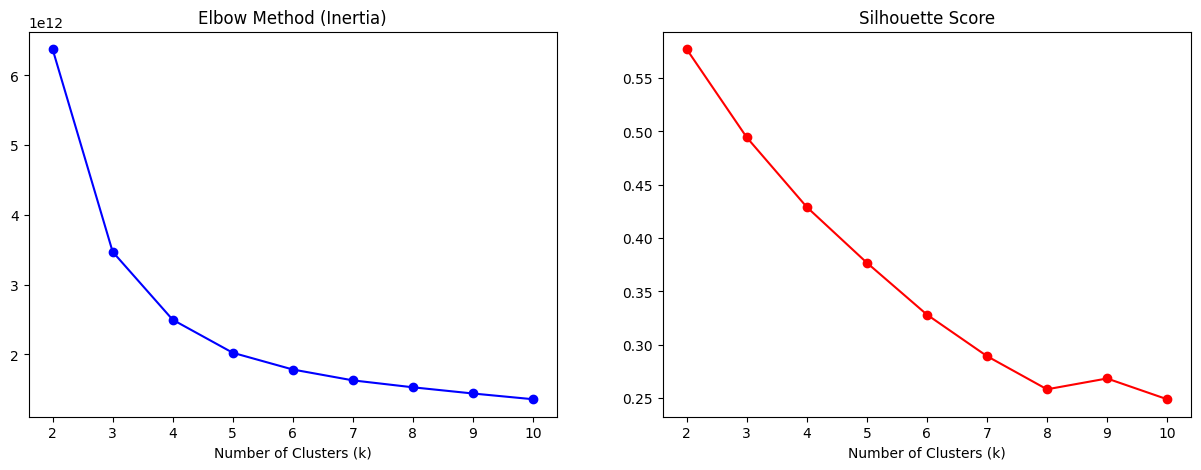

In [8]:
# EVLUATION (Silhouette Score + Elbow curve)
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OrdinalEncoder(), categorical_features)
    ])

# X_transformed is now a clean numerical matrix ready for any K value
X_transformed = preprocessor.fit_transform(clean_retail_df)

# Loop through K values to find the best K ---
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    #print(f"Starting with K = {k}")
    print(f"Computing for K = {k}")
    # We only call KMeans here, skipping the preprocessing overhead
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_transformed)
    
    #print(f"Done with K = {k}")
    # Store metrics
    inertias.append(kmeans.inertia_)
    # HERE we will first do one trick to speed up silhouette_score, sample_size=random size, random_state=42
    #silhouette_scores.append(silhouette_score(X_transformed, labels))
    #print(f"silhouette_score for K = {k}")
    silhouette_scores.append(silhouette_score(X_transformed, labels, sample_size=10000, random_state=42))
    #print(f"Done with K = {k}")

# Plot the results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')

# Silhouette Score
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')

plt.show()

Computing for K = 2
Computing for K = 3
Computing for K = 4
Computing for K = 5
Computing for K = 6
Computing for K = 7
Computing for K = 8
Computing for K = 9
Computing for K = 10


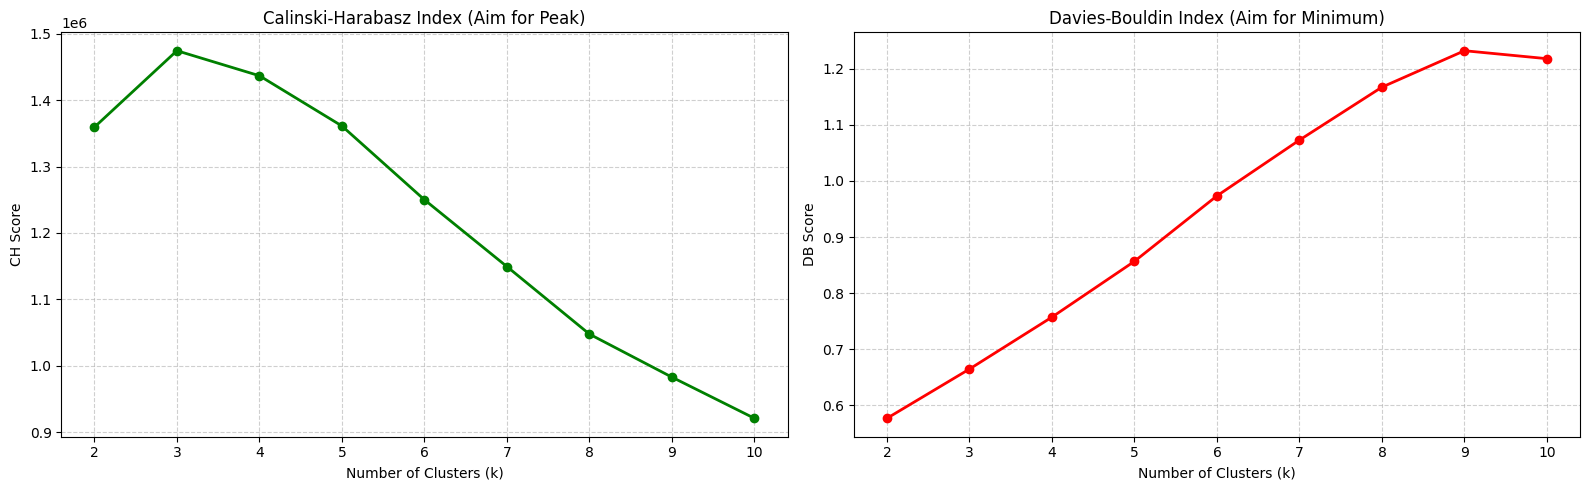

In [9]:
# differenr evaluation metrices like Calinski-Harabasz and Davies-Bouldin

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Setup range for K
ch_scores = []
db_scores = []

# Iterate and calculate (Efficiently on preprocessed data)
for k in k_range:
    print(f"Computing for K = {k}")
    # Use n_init='auto' for speed in newer sklearn versions
    model = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = model.fit_predict(X_transformed)
    
    # Calculate Calinski-Harabasz (Higher is better)
    ch = calinski_harabasz_score(X_transformed, labels)
    ch_scores.append(ch)
    
    # Calculate Davies-Bouldin (Lower is better)
    db = davies_bouldin_score(X_transformed, labels)
    db_scores.append(db)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Calinski-Harabasz
ax1.plot(k_range, ch_scores, 'go-', linewidth=2)
ax1.set_title('Calinski-Harabasz Index (Aim for Peak)', fontsize=12)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('CH Score')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Davies-Bouldin
ax2.plot(k_range, db_scores, 'ro-', linewidth=2)
ax2.set_title('Davies-Bouldin Index (Aim for Minimum)', fontsize=12)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('DB Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



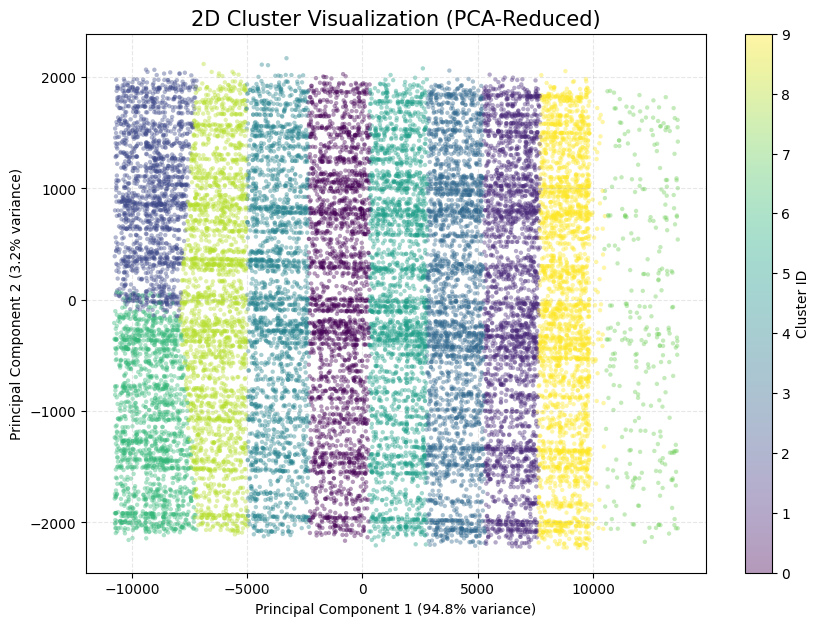

In [10]:
# VISUALIZING clusters using 2D PCA plot
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce Dimensions to 2D using PCA
# We do this so we can plot 'N' features on a 2D (X, Y) plane
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Get Cluster Labels from your fitted pipeline
# labels = final_pipeline.named_steps['kmeans'].labels_
# For this example, let's assume 'labels' is already defined from your fit
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = labels

# Handle 5 Lakh Rows: Sampling for Visualization
# Plotting 500,000 points is slow and messy. 20,000 is plenty for the "eyes".
df_sample = df_plot.sample(n=20000, random_state=42)

# Create the Visualization
plt.figure(figsize=(10, 7))

# Scatter plot with 'viridis' or 'tab10' colormap
scatter = plt.scatter(
    df_sample['PC1'], 
    df_sample['PC2'], 
    c=df_sample['Cluster'], 
    cmap='viridis', 
    s=10,          # Small point size
    alpha=0.4,     # Transparency helps see density
    edgecolors='none'
)

# Add a color bar to show which color represents which cluster
plt.colorbar(scatter, label='Cluster ID')

plt.title('2D Cluster Visualization (PCA-Reduced)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()